# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

**Sinh viên:** Đặng Đình Đoàn — 2A202602927

Notebook chạy **toàn bộ** bài lab trên Kaggle (GPU T4 x2 hoặc P100) bằng một lần *Save & Run All*:

| Bước | Ô | Nội dung | exp_id |
|---|---|---|---|
| 0 | EDA + kiểm tra | kiểm tra split (S1-S6), phân bố lớp, ảnh mẫu, loss ban đầu ≈ ln 9, overfit 1 batch, ảnh sau augmentation | — |
| 1 | Backbone | 7 backbone cùng công thức nền + DINOv2 linear probe (thưởng) | B01–B08 |
| 2 | Công thức huấn luyện | T00 x 3 seed (đo nhiễu) + 14 ablation một-yếu-tố (trục A–G) + 1 kết hợp | T00–T15 |
| 3 | Suy luận | TTA lật / 5-10 crop / đa tỉ lệ, gộp prob vs logit, dò độ phân giải, ensemble, EMA/soup, temperature scaling, AMP/FP16, gộp BN, độ trễ p50/p95/p99 | I00–I08 |
| 4 | Chung kết | F01 x 3 seed; **test chạy đúng một lần mỗi seed**; mốc T00+I00; `eval.py score` + `eval.py grade` | F01, F02, T00 |
| 5 | Sản phẩm | lệch phân phối, Grad-CAM, ma trận nhầm lẫn, biểu đồ, `results.xlsx`, gói kết quả để nộp | — |

**Mọi lựa chọn (backbone, công thức, phương pháp suy luận) được code tự động quyết định CHỈ dựa trên val**, theo luật
viết sẵn trong `code/experiments.py` (docstring của từng hàm `select_*`), và ghi kèm số liệu căn cứ vào `decisions.json`.
Không bước nào đọc nhãn test trước Bước 4.

**Cách chạy trên Kaggle**
1. *Settings*: Accelerator = **GPU T4 x2** (hoặc P100), **Internet = On** (tải repo, nhãn, trọng số timm).
2. (Khuyến nghị) Thêm dataset chứa `images.zip` của DeepWeeds (Zenodo) qua *Add Input*; nếu không, notebook tự tải từ Zenodo (~490 MB).
3. Chạy thử nhanh trước: đặt `SMOKE = True`, *Run All* (~15–25 phút, kiểm tra toàn bộ pipeline với vài bước train mỗi thí nghiệm, kết quả vào `outputs_smoke/`, KHÔNG dùng để báo cáo).
4. Chạy thật: `SMOKE = False`, **Save Version → Save & Run All (Commit)**. Ước lượng 3–5 giờ trên T4 x2 (tự đo epoch đầu trong log).
5. Tải output: `submission_export.zip` (không có checkpoint) + notebook đã chạy. Giải nén vào `submissions/2A202602927_DangDinhDoan/`.

Nếu phiên bị ngắt: tạo version mới, thêm output của version cũ làm Input và đặt `RESUME_FROM` — các lần chạy đã xong
được bỏ qua, lần chạy dở được chạy tiếp từ checkpoint epoch cuối.

## 0. Cài đặt môi trường

In [1]:
# ==== Thiết lập (sửa ở đây) ====
SMOKE = False          # True: chạy thử nhanh toàn pipeline (KHÔNG dùng số liệu để báo cáo)
RESUME_FROM = None     # ví dụ "/kaggle/input/<output-version-cu>/outputs" để chạy tiếp phiên bị ngắt
RUN_BONUS_DINOV2 = True
FORCE = {"backbone": None, "recipe": None, "inference": None}   # None = luật tự động trên val

REPO_URL = "https://github.com/Doan0904/K4-Track4-Day2-Deeplearning-Advance.git"
REPO_DIR = "/tmp/lab_repo" if __import__("os").path.isdir("/kaggle") else "lab_repo"
WORK = "/kaggle/working" if __import__("os").path.isdir("/kaggle/working") else "."

In [2]:
import os, sys, subprocess, platform, time, json, glob, shutil
os.makedirs(os.path.dirname(REPO_DIR) or ".", exist_ok=True)
if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
print(subprocess.run(["git", "-C", REPO_DIR, "log", "-1", "--format=%H %s"], capture_output=True, text=True).stdout)

!pip -q install timm openpyxl

CODE_DIR = glob.glob(f"{REPO_DIR}/submissions/*2A202602927*/code")[0]
sys.path.insert(0, REPO_DIR)      # eval.py gốc (không sửa)
sys.path.insert(0, CODE_DIR)      # code đã hoàn thiện từ starter/

import numpy as np, pandas as pd, torch, torchvision, timm
print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__, "| CUDA", torch.version.cuda)
print("GPU:", [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())] or "KHÔNG CÓ GPU")
print("CPU:", os.cpu_count(), "| code:", CODE_DIR)
!nvidia-smi

Cloning into '/tmp/lab_repo'...


cf0af3e00ef15393f09b820e64c6913a59adaf6e Fix Step 3 crash: run each ensemble member at its own training resolution

python 3.13.15 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | timm 1.0.29 | CUDA 12.8
GPU: ['Tesla T4', 'Tesla T4']
CPU: 4 | code: /tmp/lab_repo/submissions/2A202602927_DangDinhDoan/code
Sun Oct  4 06:54:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4   

In [3]:
# Test tự viết (CPU, không cần dữ liệu): focal gamma=0 == CE, CutMix lam = diện tích thật, gộp BN, TS, ...
r = subprocess.run([sys.executable, "-m", "unittest", "test_code"], cwd=CODE_DIR, capture_output=True, text=True,
                   env=dict(os.environ, CUDA_VISIBLE_DEVICES=""))
print(r.stderr[-3000:])
assert r.returncode == 0, "test_code thất bại"

.............................
----------------------------------------------------------------------
Ran 29 tests in 7.799s

OK



### Tải dữ liệu
Ảnh: tìm `images.zip` / thư mục ảnh trong `/kaggle/input`, nếu không có thì tải từ Zenodo; kiểm tra MD5
`b7b30f96d466fba86016aa5a26606e0f`. Nhãn và file chia fold: tải nguyên bản từ GitHub của tác giả (không sửa).
Sau đó giải mã toàn bộ ảnh một lần vào `/tmp/deepweeds_u8.npy` (cache uint8, ~3,4 GB) để DataLoader
không phải giải mã JPEG mỗi epoch (Kaggle chỉ có 4 vCPU). Cache chỉ tăng tốc, ảnh giống hệt ảnh gốc.

In [4]:
import hashlib, zipfile, urllib.request
DATA = "/tmp/deepweeds" if os.path.isdir("/kaggle") else "data"
IMAGES_DIR, LABELS_DIR = f"{DATA}/images", f"{DATA}/labels"
os.makedirs(IMAGES_DIR, exist_ok=True); os.makedirs(LABELS_DIR, exist_ok=True)
MD5 = "b7b30f96d466fba86016aa5a26606e0f"
FIRST = "20160928-140314-0.jpg"

def md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

n_have = len(glob.glob(f"{IMAGES_DIR}/*.jpg"))
if n_have < 17509:
    zips = [p for p in glob.glob("/kaggle/input/**/images.zip", recursive=True)]
    dirs = [os.path.dirname(p) for p in glob.glob(f"/kaggle/input/**/{FIRST}", recursive=True)]
    if zips:
        src_zip = zips[0]
    elif dirs and len(glob.glob(f"{dirs[0]}/*.jpg")) >= 17509:
        src_zip = None
        print("Dùng ảnh đã giải nén sẵn trong input:", dirs[0])
        IMAGES_DIR = dirs[0]
    else:
        src_zip = f"{DATA}/images.zip"
        if not os.path.exists(src_zip):
            print("Tải images.zip từ Zenodo ...")
            urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", src_zip)
    if src_zip:
        h = md5(src_zip)
        print("MD5", h)
        assert h == MD5, f"MD5 sai: {h}"
        with zipfile.ZipFile(src_zip) as z:
            for m in z.infolist():
                if m.filename.endswith(".jpg"):
                    m.filename = os.path.basename(m.filename)   # zip giải nén phẳng; gom vào images/
                    z.extract(m, IMAGES_DIR)
print("Số ảnh:", len(glob.glob(f"{IMAGES_DIR}/*.jpg")), "trong", IMAGES_DIR)

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    urllib.request.urlretrieve(f"{BASE}/{name}.csv", f"{LABELS_DIR}/{name}.csv")
!ls -la {LABELS_DIR}; wc -l {LABELS_DIR}/*.csv

Dùng ảnh đã giải nén sẵn trong input: /kaggle/input/datasets/ngan1234/cv-lab2
Số ảnh: 17509 trong /kaggle/input/datasets/ngan1234/cv-lab2
total 1012
drwxr-xr-x 2 root root   4096 Oct  4 06:58 .
drwxr-xr-x 4 root root   4096 Oct  4 06:55 ..
-rw-r--r-- 1 root root 598898 Oct  4 06:58 labels.csv
-rw-r--r-- 1 root root  84183 Oct  4 06:58 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  4 06:58 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  4 06:58 val_subset0.csv
  17510 /tmp/deepweeds/labels/labels.csv
   3508 /tmp/deepweeds/labels/test_subset0.csv
  10502 /tmp/deepweeds/labels/train_subset0.csv
   3502 /tmp/deepweeds/labels/val_subset0.csv
  35022 total


In [5]:
import dataset as D
CACHE = ("/tmp" if os.path.isdir("/kaggle") else DATA) + "/deepweeds_u8.npy"
t0 = time.time()
try:
    D.build_cache(pd.read_csv(f"{LABELS_DIR}/labels.csv")["Filename"], IMAGES_DIR, CACHE, workers=os.cpu_count())
    print(f"cache sẵn sàng ({time.time() - t0:.0f}s):", CACHE)
except OSError as e:  # hết đĩa -> đọc JPEG trực tiếp
    print("Không tạo được cache, đọc JPEG trực tiếp:", e)
    CACHE = None
!df -h /tmp /kaggle/working 2>/dev/null; free -g

cache sẵn sàng (207s): /tmp/deepweeds_u8.npy
Filesystem      Size  Used Avail Use% Mounted on
overlay         8.0T  7.0T  1.1T  87% /
/dev/loop2       20G  160K   20G   1% /kaggle/working
               total        used        free      shared  buff/cache   available
Mem:              31           1          16           0          12          29
Swap:              0           0           0


In [6]:
from experiments import Lab
import analysis as AN

OUT = f"{WORK}/outputs_smoke" if SMOKE else f"{WORK}/outputs"
if RESUME_FROM and not os.path.exists(f"{OUT}/decisions.json"):
    shutil.copytree(RESUME_FROM, OUT, dirs_exist_ok=True)
    print("Đã chép kết quả phiên trước từ", RESUME_FROM)
lab = Lab(OUT, IMAGES_DIR, LABELS_DIR, cache_path=CACHE, smoke=SMOKE)
print("OUT =", OUT, "| số GPU dùng song song:", lab.n_gpus, "| SMOKE =", SMOKE)
TIMER = {}
def tic(name): TIMER[name] = time.time(); print(f"=== {name} bắt đầu {time.strftime('%H:%M:%S')}")
def toc(name): print(f"=== {name} xong sau {(time.time() - TIMER[name]) / 60:.1f} phút")

OUT = /kaggle/working/outputs | số GPU dùng song song: 2 | SMOKE = False


## Bước 0 — EDA và kiểm tra pipeline
Kiểm tra bắt buộc (README mục 2.1): số ảnh mỗi tập/lớp, giao từng cặp tập rỗng, hợp đúng 17.509 ảnh, mọi file tồn tại.
Thêm: nhãn trong subset so với `labels.csv` (chỉ ghi lại chỗ lệch, không sửa CSV theo S1).

In [7]:
tic("Bước 0")
eda = AN.eda(IMAGES_DIR, LABELS_DIR, OUT)
print("Lệch nhãn subset vs labels.csv:", eda["label_mismatch_vs_labels_csv"])
display(pd.read_csv(f"{OUT}/eda_class_counts.csv", index_col=0))

=== Bước 0 bắt đầu 07:02:06
Số ảnh: {'train': 10501, 'val': 3501, 'test': 3507} (tổng 17509); tỉ lệ {'train': 0.5997, 'val': 0.2, 'test': 0.2003}
Giao: {'train&val': 0, 'train&test': 0, 'val&test': 0}; hợp = 17509 (kỳ vọng 17509); thiếu file: 0
CẢNH BÁO: 1 ảnh có nhãn subset khác labels.csv (giữ nguyên subset): [{'split': 'train', 'Filename': '20170714-110407-3.jpg', 'subset_label': 0, 'labels_csv_label': 1}]
                train   val  test   all
Chinee Apple      675   225   226  1126
Lantana           637   213   213  1063
Parkinsonia       618   206   207  1031
Parthenium        613   204   205  1022
Prickly Acacia    637   212   213  1062
Rubber Vine       605   202   202  1009
Siam Weed         644   215   215  1074
Snake Weed        609   203   204  1016
Negatives        5463  1821  1822  9106
Kích thước ảnh: {'256x256': 17509}; mode {'RGB': 17509}
Mean/std kênh (train, 2000 ảnh): [0.3785, 0.3885, 0.3786] / [0.2367, 0.2351, 0.2328]
Tỉ lệ lớp lớn nhất / nhỏ nhất: 9.02
Lệch nhãn 

,train,val,test,all,paper_table1,diff_vs_paper,pct_all
Chinee Apple,675,225,226,1126,1125,1,6.430978
Lantana,637,213,213,1063,1064,-1,6.071163
Parkinsonia,618,206,207,1031,1031,0,5.888400
Parthenium,613,204,205,1022,1022,0,5.836998
Prickly Acacia,637,212,213,1062,1062,0,6.065452
Rubber Vine,605,202,202,1009,1009,0,5.762751
Siam Weed,644,215,215,1074,1074,0,6.133988
Snake Weed,609,203,204,1016,1016,0,5.802730
Negatives,5463,1821,1822,9106,9106,0,52.007539


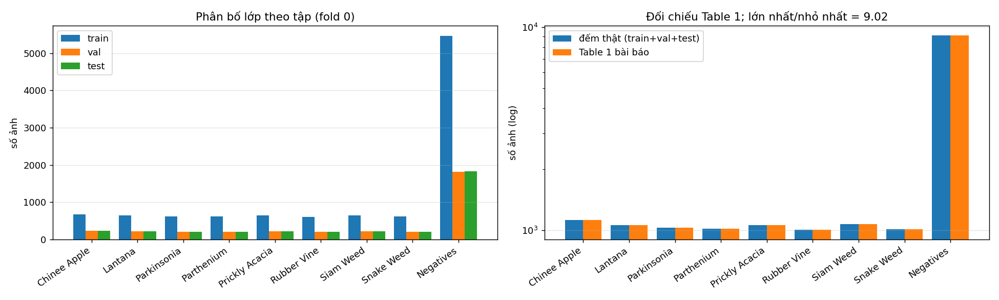

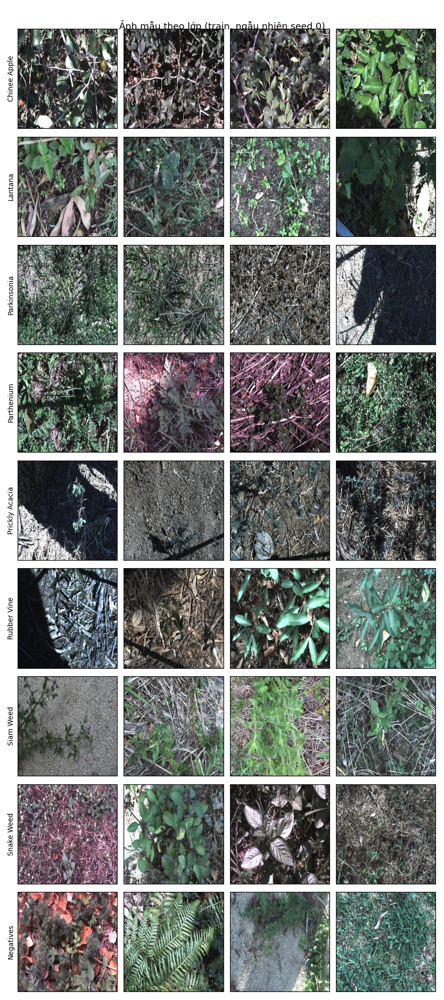

In [8]:
from IPython.display import Image as IImage, display
display(IImage(f"{OUT}/figures/eda_class_distribution.png"))
display(IImage(f"{OUT}/figures/eda_samples.png", width=600))

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

{
  "backbone": "resnet50.a1_in1k",
  "expected_initial_loss": 2.1972245773362196,
  "initial_loss": 2.185052812099457,
  "initial_pred_entropy": 2.1950087547302246,
  "focal_gamma0_minus_ce": 0.0,
  "overfit_final_loss": 0.0013494612649083138,
  "overfit_ok": true
}


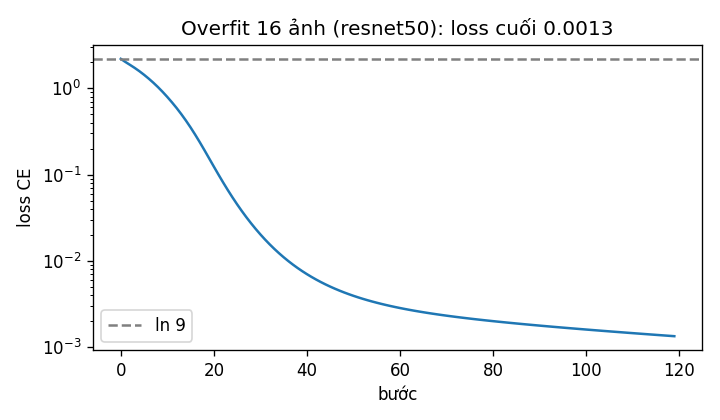

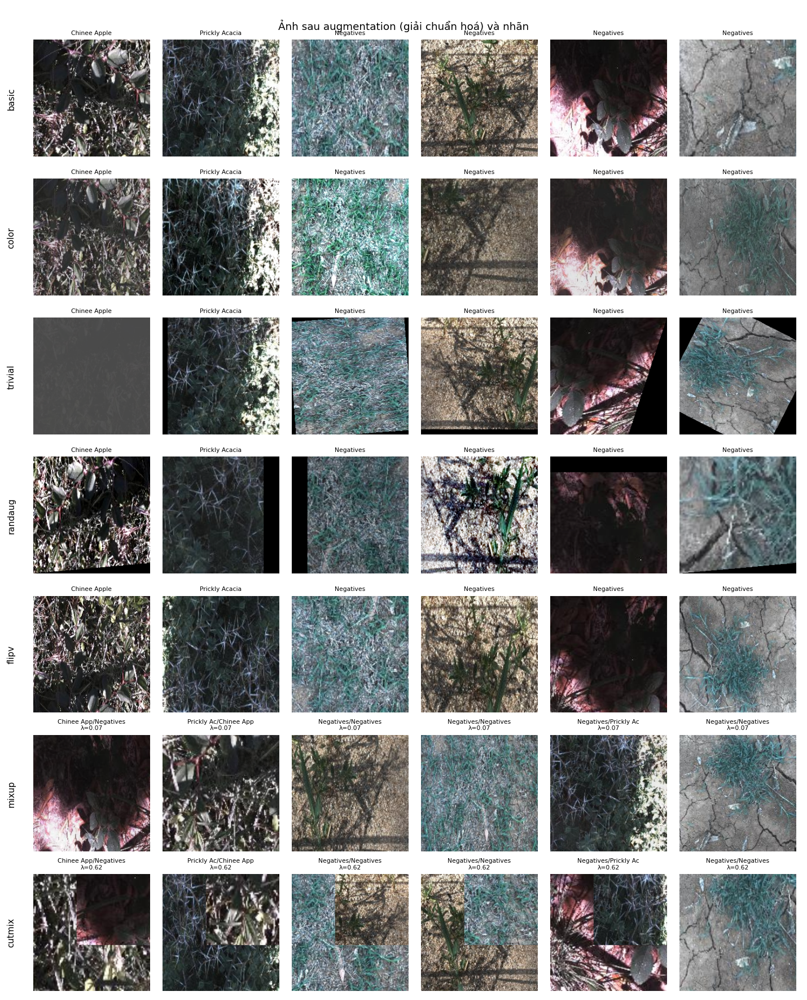

=== Bước 0 xong sau 1.0 phút


In [9]:
# Kiểm tra pipeline (slide trang 59, GUIDE mục 1.3): seed cố định; loss ban đầu ≈ ln 9 = 2.197;
# overfit 16 ảnh tới loss ≈ 0; ảnh sau augmentation (giải chuẩn hoá) khớp nhãn; focal gamma=0 == CE.
san = AN.sanity_checks(lab)
assert abs(san["initial_loss"] - np.log(9)) < 0.5, "loss ban đầu lệch xa ln 9"
assert san["overfit_ok"], "không overfit được một batch nhỏ"
display(IImage(f"{OUT}/sanity/overfit_one_batch.png"))
display(IImage(f"{OUT}/sanity/augmentations.png", width=900))
toc("Bước 0")

## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE mục 1.4: AdamW, LR backbone 1e-4 / head 1e-3, wd 0,05 không áp cho norm/bias,
warmup 1 epoch + cosine, CE, batch 64, 12 epoch, AMP, RandomResizedCrop 224 + lật ngang; val/test center-crop 224 từ ảnh 256),
cùng seed 0. Chọn checkpoint theo macro-F1 val. Trọng số timm đều chỉ huấn luyện trên ImageNet-1k (tag ghi trong bảng).

In [10]:
tic("Bước 1")
bt = lab.stage1_backbones(bonus=RUN_BONUS_DINOV2)
display(bt.round(4))
dec_b = lab.select_backbone(force=FORCE["backbone"])
print(json.dumps({k: v for k, v in dec_b.items() if k != "table"}, indent=2, ensure_ascii=False))
toc("Bước 1")

=== Bước 1 bắt đầu 07:03:09
[stage1] 8 job, 0 đã xong, còn 8; GPU = 2
[gpu1] [B05 seed0] ep 01/12 loss 1.0067 | val loss 0.3619 F1 0.8530 top1 0.8823 | 59s+9s
[gpu0] [B03 seed0] ep 01/12 loss 1.2446 | val loss 0.4727 F1 0.7922 top1 0.8518 | 77s+29s
[gpu1] [B05 seed0] ep 02/12 loss 0.3698 | val loss 0.3134 F1 0.8668 top1 0.8986 | 60s+8s
[gpu0] [B03 seed0] ep 02/12 loss 0.3857 | val loss 0.2987 F1 0.8701 top1 0.9060 | 49s+6s
[gpu1] [B05 seed0] ep 03/12 loss 0.2728 | val loss 0.2812 F1 0.8805 top1 0.9060 | 63s+8s
[gpu0] [B03 seed0] ep 03/12 loss 0.2421 | val loss 0.2096 F1 0.9112 top1 0.9343 | 48s+6s
[gpu0] [B03 seed0] ep 04/12 loss 0.1952 | val loss 0.2059 F1 0.9099 top1 0.9349 | 48s+6s
[gpu1] [B05 seed0] ep 04/12 loss 0.2121 | val loss 0.2442 F1 0.8885 top1 0.9192 | 63s+8s
[gpu0] [B03 seed0] ep 05/12 loss 0.1579 | val loss 0.1465 F1 0.9382 top1 0.9532 | 48s+6s
[gpu1] [B05 seed0] ep 05/12 loss 0.1765 | val loss 0.1577 F1 0.9317 top1 0.9503 | 63s+8s
[gpu0] [B03 seed0] ep 06/12 loss 0.1306

,exp_id,backbone,timm_name,tag,init,params_M,gmacs,val_macro_f1,val_top1,val_f1_chinee_apple,val_f1_snake_weed,best_epoch,time_train_per_epoch_s,latency_b1_p50_ms,latency_b1_p95_ms
0,B01,resnet50,resnet50.a1_in1k,a1_in1k,finetune,23.5265,4.0872,0.7989,0.8558,0.6261,0.7198,11,34.3335,6.2639,11.6587
1,B02,resnext50,resnext50_32x4d.a1h_in1k,a1h_in1k,finetune,22.9983,4.2285,0.7652,0.8143,0.7019,0.7879,9,42.3566,11.5067,15.4343
2,B03,convnext_tiny,convnext_tiny.fb_in1k,fb_in1k,finetune,27.8270,4.4548,0.9557,0.9666,0.9161,0.9073,10,50.7133,5.6343,6.1714
3,B04,deit_small,deit_small_patch16_224.fb_in1k,fb_in1k,finetune,21.6691,4.2408,0.9476,0.9632,0.8828,0.8873,12,32.8012,5.2571,5.5231
4,B05,swin_tiny,swin_tiny_patch4_window7_224.ms_in1k,ms_in1k,finetune,27.5263,4.4898,0.9580,0.9700,0.9133,0.9223,12,62.0554,9.6337,17.6531
5,B06,efficientnet_b0,efficientnet_b0.ra_in1k,ra_in1k,finetune,4.0191,0.3845,0.7514,0.8181,0.6305,0.7206,12,32.1999,14.1980,17.3129
6,B07,mobilenetv3,mobilenetv3_large_100.ra_in1k,ra_in1k,finetune,4.2136,0.2153,0.6364,0.7418,0.6761,0.5629,12,23.3115,6.4529,6.9680
7,B08,dinov2_small,vit_small_patch14_dinov2.lvd142m,lvd142m,frozen,21.6323,5.5149,0.8734,0.8972,0.8329,0.8111,11,17.3282,6.6309,11.3334


{
  "backbone": "convnext_tiny",
  "from_exp": "B03",
  "forced": false,
  "rule": "macro-F1 val >= max - 0.005 (1 seed), rồi thời gian train/epoch nhỏ nhất",
  "best_f1": 0.9580253669140048,
  "candidates": [
    "convnext_tiny",
    "swin_tiny"
  ]
}
=== Bước 1 xong sau 36.0 phút


## Bước 2 — Công thức huấn luyện (trục A–G)
`T00` chạy 3 seed để đo nhiễu (std). Mỗi `T01..T14` khác `T00` **đúng một yếu tố**. Sau đó `T15` kết hợp
các yếu tố thắng (luật trong `select_combo`), và chọn công thức chung kết (`select_recipe`).

In [11]:
tic("Bước 2")
tt = lab.stage2_ablation()
display(tt.round(4))
print("T00:", lab.t00_stats())

=== Bước 2 bắt đầu 07:39:10
[stage2] 17 job, 0 đã xong, còn 17; GPU = 2
[gpu0] [T00 seed0] ep 01/12 loss 1.2446 | val loss 0.4727 F1 0.7922 top1 0.8518 | 79s+29s
[gpu1] [T00 seed1] ep 01/12 loss 1.1977 | val loss 0.4933 F1 0.7844 top1 0.8449 | 74s+29s
[gpu0] [T00 seed0] ep 02/12 loss 0.3857 | val loss 0.2987 F1 0.8701 top1 0.9060 | 49s+6s
[gpu1] [T00 seed1] ep 02/12 loss 0.3810 | val loss 0.2630 F1 0.8998 top1 0.9212 | 47s+6s
[gpu1] [T00 seed1] ep 03/12 loss 0.2292 | val loss 0.1912 F1 0.9180 top1 0.9389 | 47s+6s
[gpu0] [T00 seed0] ep 03/12 loss 0.2421 | val loss 0.2096 F1 0.9112 top1 0.9343 | 49s+6s
[gpu1] [T00 seed1] ep 04/12 loss 0.1815 | val loss 0.2141 F1 0.9155 top1 0.9340 | 48s+6s
[gpu0] [T00 seed0] ep 04/12 loss 0.1952 | val loss 0.2059 F1 0.9099 top1 0.9349 | 49s+6s
[gpu0] [T00 seed0] ep 05/12 loss 0.1579 | val loss 0.1465 F1 0.9382 top1 0.9532 | 49s+6s
[gpu1] [T00 seed1] ep 05/12 loss 0.1432 | val loss 0.1406 F1 0.9401 top1 0.9560 | 48s+6s
[gpu0] [T00 seed0] ep 06/12 loss 0.1

,exp_id,desc,backbone,axis,slot,diff_vs_T00,seed,val_macro_f1,val_top1,delta_vs_T00_mean,T00_std,beyond_noise,val_f1_chinee_apple,val_f1_snake_weed,val_ece,best_epoch,time_train_per_epoch_s,best_raw_val_macro_f1,best_ema_val_macro_f1
0,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),0,0.9557,0.9666,0.0018,0.0016,None,0.9161,0.9073,0.0089,10,51.0369,0.9557,NaN
1,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),1,0.9533,0.9649,-0.0005,0.0016,None,0.8966,0.9113,0.0081,9,50.3297,0.9533,NaN
2,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),2,0.9526,0.9646,-0.0013,0.0016,None,0.9203,0.9024,0.0059,11,48.8269,0.9526,NaN
3,T01,scratch,convnext_tiny,A,init,init=scratch,0,0.3107,0.5547,-0.6432,0.0016,True,0.2449,0.2667,0.0272,12,48.4309,0.3107,NaN
4,T02,frozen,convnext_tiny,A,init,init=frozen,0,0.6891,0.7658,-0.2648,0.0016,True,0.6154,0.5880,0.0612,8,19.6120,0.6891,NaN
5,T03,color,convnext_tiny,B,aug,aug=color,0,0.9479,0.9606,-0.0060,0.0016,True,0.8910,0.9113,0.0085,12,70.3242,0.9479,NaN
6,T04,trivialaug,convnext_tiny,B,aug,aug=trivial,0,0.9516,0.9640,-0.0023,0.0016,True,0.9035,0.8947,0.0072,8,50.4087,0.9516,NaN
7,T05,vflip,convnext_tiny,B,aug,aug=flipv,0,0.9556,0.9677,0.0017,0.0016,True,0.9124,0.9087,0.0078,11,48.4498,0.9556,NaN
8,T06,mixup,convnext_tiny,B,mix,"mix=mixup, mix_alpha=0.2",0,0.9551,0.9657,0.0012,0.0016,False,0.8962,0.9095,0.0157,8,49.6251,0.9551,NaN
9,T07,cutmix,convnext_tiny,B,mix,"mix=cutmix, mix_alpha=1.0",0,0.9475,0.9603,-0.0064,0.0016,True,0.8837,0.8842,0.0288,12,49.0138,0.9475,NaN


T00: {'f1': [0.9556843057781905, 0.9533292091227352, 0.9525920186632324], 'mean': 0.9538685111880527, 'std': 0.0016151454852662026, 'top1_mean': 0.9653432352661144, 'top1_std': 0.0010813878598115152, 'noise': 0.0016151454852662026}


In [12]:
dec_c = lab.select_combo()
print(json.dumps({k: v for k, v in dec_c.items() if k != "candidates"}, indent=2, ensure_ascii=False))
lab.stage2_combo()
dec_r = lab.select_recipe(force=FORCE["recipe"])
print(json.dumps(dec_r, indent=2, ensure_ascii=False))
display(lab.training_table().round(4))
toc("Bước 2")

{
  "from": [
    "T14",
    "T08",
    "T05"
  ],
  "overrides": {
    "img_size": 256,
    "loss": "ls",
    "label_smoothing": 0.1,
    "aug": "flipv"
  },
  "note": "các yếu tố có Δ > std(T00)",
  "noise_threshold": 0.0016151454852662026,
  "T00": {
    "f1": [
      0.9556843057781905,
      0.9533292091227352,
      0.9525920186632324
    ],
    "mean": 0.9538685111880527,
    "std": 0.0016151454852662026,
    "top1_mean": 0.9653432352661144,
    "top1_std": 0.0010813878598115152,
    "noise": 0.0016151454852662026
  }
}
[stage2_combo] 1 job, 0 đã xong, còn 1; GPU = 2
[T15 seed0] ep 01/12 loss 1.4160 | val loss 0.5096 F1 0.8015 top1 0.8509 | 90s+34s
[T15 seed0] ep 02/12 loss 0.7990 | val loss 0.3272 F1 0.8960 top1 0.9252 | 62s+8s
[T15 seed0] ep 03/12 loss 0.6856 | val loss 0.2629 F1 0.9179 top1 0.9403 | 63s+8s
[T15 seed0] ep 04/12 loss 0.6362 | val loss 0.2204 F1 0.9386 top1 0.9523 | 63s+8s
[T15 seed0] ep 05/12 loss 0.6159 | val loss 0.2148 F1 0.9454 top1 0.9586 | 63s+8s
[T15 see

,exp_id,desc,backbone,axis,slot,diff_vs_T00,seed,val_macro_f1,val_top1,delta_vs_T00_mean,T00_std,beyond_noise,val_f1_chinee_apple,val_f1_snake_weed,val_ece,best_epoch,time_train_per_epoch_s,best_raw_val_macro_f1,best_ema_val_macro_f1
0,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),0,0.9557,0.9666,0.0018,0.0016,None,0.9161,0.9073,0.0089,10,51.0369,0.9557,NaN
1,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),1,0.9533,0.9649,-0.0005,0.0016,None,0.8966,0.9113,0.0081,9,50.3297,0.9533,NaN
2,T00,baseline,convnext_tiny,-,-,baseline (công thức nền),2,0.9526,0.9646,-0.0013,0.0016,None,0.9203,0.9024,0.0059,11,48.8269,0.9526,NaN
3,T01,scratch,convnext_tiny,A,init,init=scratch,0,0.3107,0.5547,-0.6432,0.0016,True,0.2449,0.2667,0.0272,12,48.4309,0.3107,NaN
4,T02,frozen,convnext_tiny,A,init,init=frozen,0,0.6891,0.7658,-0.2648,0.0016,True,0.6154,0.5880,0.0612,8,19.6120,0.6891,NaN
5,T03,color,convnext_tiny,B,aug,aug=color,0,0.9479,0.9606,-0.0060,0.0016,True,0.8910,0.9113,0.0085,12,70.3242,0.9479,NaN
6,T04,trivialaug,convnext_tiny,B,aug,aug=trivial,0,0.9516,0.9640,-0.0023,0.0016,True,0.9035,0.8947,0.0072,8,50.4087,0.9516,NaN
7,T05,vflip,convnext_tiny,B,aug,aug=flipv,0,0.9556,0.9677,0.0017,0.0016,True,0.9124,0.9087,0.0078,11,48.4498,0.9556,NaN
8,T06,mixup,convnext_tiny,B,mix,"mix=mixup, mix_alpha=0.2",0,0.9551,0.9657,0.0012,0.0016,False,0.8962,0.9095,0.0157,8,49.6251,0.9551,NaN
9,T07,cutmix,convnext_tiny,B,mix,"mix=cutmix, mix_alpha=1.0",0,0.9475,0.9603,-0.0064,0.0016,True,0.8837,0.8842,0.0288,12,49.0138,0.9475,NaN


=== Bước 2 xong sau 116.6 phút


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Trên **val**, model của công thức đã chọn (seed 0), không huấn luyện lại. Độ trễ: warmup 10 lần, `torch.cuda.synchronize()`
trước/sau, 100 lần đo, p50/p95/p99; batch 1 và 32; FP32 / AMP / FP16; chỉ tính forward (+ tạo view TTA trên GPU),
không tính giải mã/tiền xử lý CPU.

In [13]:
tic("Bước 3")
inf = lab.stage3_inference()
display(inf.round(4))
dec_i = lab.select_inference(force=FORCE["inference"])
print(json.dumps(dec_i, indent=2, ensure_ascii=False))
print("TTA đổi nhãn (val):", json.load(open(f"{OUT}/inference/tta_flips.json")))
display(pd.read_csv(f"{OUT}/inference/latency.csv").round(3))
toc("Bước 3")

=== Bước 3 bắt đầu 09:35:46


,exp_id,method,model,K,space,val_macro_f1,val_top1,val_ece,val_nll,val_f1_chinee_apple,val_f1_snake_weed,lat_p50_ms,lat_p95_ms,lat_p99_ms,throughput_img_s,rel_cost_vs_I00,note
0,I00,1 view (center-crop),T15_seed0 (convnext_tiny),1,-,0.9637,0.9720,0.0874,0.1767,0.9252,0.9238,6.4813,6.7226,6.7513,181.4206,1.0000,"Resize 293 -> CenterCrop 256, fp32"
1,I01,TTA lật ngang,T15_seed0 (convnext_tiny),2,prob,0.9632,0.9717,0.0878,0.1756,0.9206,0.9287,11.8724,12.0279,12.2420,84.2292,1.8318,stacked batch 2; tuần tự p50 = 13.10 ms
2,I02a,TTA 5 crop,T15_seed0 (convnext_tiny),5,prob,0.9675,0.9751,0.0923,0.1749,0.9367,0.9300,27.4335,28.3769,28.5356,36.4518,4.2327,"4 góc + giữa, crop 256 từ ảnh 293"
3,I02b,TTA 10 crop,T15_seed0 (convnext_tiny),10,prob,0.9676,0.9751,0.0922,0.1748,0.9367,0.9327,54.2697,55.5660,56.3275,18.4265,8.3733,5 crop + bản lật
4,I02c,TTA nhiều tỉ lệ,T15_seed0 (convnext_tiny),3,prob,0.9673,0.9751,0.0971,0.1800,0.9414,0.9403,24.1493,24.7858,24.8162,41.4090,3.7260,center-crop 256 + ảnh nguyên 293 + ảnh nguyên ...
5,I03a,I01 gộp LOGIT,T15_seed0 (convnext_tiny),2,logit,0.9632,0.9717,0.0872,0.1753,0.9206,0.9287,11.8724,12.0279,12.2420,84.2292,1.8318,"cùng view với I01, khác cách gộp"
6,I03b,I02a gộp LOGIT,T15_seed0 (convnext_tiny),5,logit,0.9670,0.9749,0.0901,0.1730,0.9345,0.9300,27.4335,28.3769,28.5356,36.4518,4.2327,"cùng view với I02a, khác cách gộp"
7,I03c,I02b gộp LOGIT,T15_seed0 (convnext_tiny),10,logit,0.9676,0.9751,0.0892,0.1729,0.9367,0.9327,54.2697,55.5660,56.3275,18.4265,8.3733,"cùng view với I02b, khác cách gộp"
8,I03d,I02c gộp LOGIT,T15_seed0 (convnext_tiny),3,logit,0.9667,0.9746,0.0934,0.1781,0.9391,0.9403,24.1493,24.7858,24.8162,41.4090,3.7260,"cùng view với I02c, khác cách gộp"
9,I04_288,độ phân giải kiểm tra 288,T15_seed0 (convnext_tiny),1,-,0.9511,0.9609,0.0828,0.2080,0.8981,0.9133,7.8720,8.2322,8.2734,127.0320,1.2146,Resize 329 -> CenterCrop 288 (train 256)


{
  "exp_id": "I02b",
  "method": "TTA 10 crop",
  "K": 10,
  "space": "prob",
  "val_macro_f1": 0.9675606029366276,
  "I00_val_macro_f1": 0.9637072429690487,
  "best_candidate": "I02b",
  "best_candidate_f1": 0.9675606029366276,
  "min_gain": 0.002,
  "forced": false,
  "temperature_scaling": true,
  "realtime": "1 view + TS, FP32"
}
TTA đổi nhãn (val): {'I01': {'right_to_wrong': 7, 'wrong_to_right': 6, 'changed': 14}, 'I02b': {'right_to_wrong': 10, 'wrong_to_right': 21, 'changed': 33}}


,config,gpu,torch,cudnn_benchmark,dtype,batch,img_size,bn_fused,includes_preprocessing,p50,p95,p99,mean,std,n,warmup,images_per_s,k_views,mode,k_models
0,I00 1-view fp32,Tesla T4,2.11.0+cu128,True,fp32,1,256,False,False,6.481,6.723,6.751,6.520,0.096,100,10,154.290,NaN,NaN,NaN
1,I00 b32 fp32,Tesla T4,2.11.0+cu128,True,fp32,32,256,False,False,176.386,178.975,179.652,176.254,1.788,50,10,181.421,NaN,NaN,NaN
2,I01 hflip K=2 stacked,Tesla T4,2.11.0+cu128,True,fp32,1,256,False,False,11.872,12.028,12.242,11.841,0.136,100,10,84.229,2.0,stacked,NaN
3,I01 hflip K=2 sequential,Tesla T4,2.11.0+cu128,True,fp32,1,256,False,False,13.103,13.383,13.450,13.126,0.219,100,10,76.318,2.0,sequential,NaN
4,I02a 5-crop,Tesla T4,2.11.0+cu128,True,fp32,1,256,False,False,27.433,28.377,28.536,27.445,0.547,100,10,36.452,5.0,stacked,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,B08 dinov2_small,Tesla T4,2.11.0+cu128,True,fp32,32,224,False,False,149.126,152.289,152.665,149.329,1.710,50,10,214.584,NaN,NaN,NaN
63,B08 dinov2_small,Tesla T4,2.11.0+cu128,True,amp,1,224,False,False,7.321,7.926,8.938,7.381,0.367,100,10,136.599,NaN,NaN,NaN
64,B08 dinov2_small,Tesla T4,2.11.0+cu128,True,amp,32,224,False,False,45.354,46.057,46.156,45.437,0.339,50,10,705.559,NaN,NaN,NaN
65,B08 dinov2_small,Tesla T4,2.11.0+cu128,True,fp16,1,224,False,False,5.380,5.824,6.035,5.425,0.237,100,10,185.862,NaN,NaN,NaN


=== Bước 3 xong sau 12.1 phút


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Cấu hình đã chốt trên val (`decisions.json`): backbone + công thức + suy luận.
2. Train `F01` với seed 0, 1, 2. Mốc `T00` (+ `I00`) dùng lại 3 seed đã train ở Bước 2.
3. Mỗi model chạy qua test **đúng một lượt** (mọi view cần cho F01 và bản thời gian thực F02 lấy trong cùng lượt đó),
   T khớp trên val của từng seed. Ghi `predictions/F01_seed<k>_test.csv`, `F01_uncal_*`, `F02_*` (nếu F01 dùng TTA), `T00_*`,
   kèm bản `_val.csv`. File test đã có thì KHÔNG chạy lại.
4. Chỉ số tính bằng `eval.py score` và `eval.py grade` (repo gốc, không sửa).

In [14]:
tic("Bước 4")
res4 = lab.stage4_final()
print(res4)
toc("Bước 4")

=== Bước 4 bắt đầu 09:47:50
[stage4] 3 job, 0 đã xong, còn 3; GPU = 2
[gpu1] [F01 seed0] ep 01/12 loss 1.4160 | val loss 0.5097 F1 0.8013 top1 0.8509 | 89s+36s
[gpu0] [F01 seed1] ep 01/12 loss 1.3805 | val loss 0.5061 F1 0.8093 top1 0.8675 | 97s+37s
[gpu0] [F01 seed1] ep 02/12 loss 0.7753 | val loss 0.2860 F1 0.9167 top1 0.9392 | 63s+10s
[gpu1] [F01 seed0] ep 02/12 loss 0.7990 | val loss 0.3272 F1 0.8960 top1 0.9252 | 59s+10s
[gpu1] [F01 seed0] ep 03/12 loss 0.6855 | val loss 0.2629 F1 0.9179 top1 0.9403 | 61s+9s
[gpu0] [F01 seed1] ep 03/12 loss 0.6696 | val loss 0.2256 F1 0.9357 top1 0.9537 | 63s+10s
[gpu1] [F01 seed0] ep 04/12 loss 0.6362 | val loss 0.2204 F1 0.9389 top1 0.9526 | 62s+9s
[gpu0] [F01 seed1] ep 04/12 loss 0.6330 | val loss 0.2313 F1 0.9339 top1 0.9517 | 63s+9s
[gpu1] [F01 seed0] ep 05/12 loss 0.6159 | val loss 0.2147 F1 0.9454 top1 0.9586 | 63s+9s
[gpu0] [F01 seed1] ep 05/12 loss 0.6081 | val loss 0.2051 F1 0.9540 top1 0.9649 | 63s+9s
[gpu1] [F01 seed0] ep 06/12 loss 0.

In [15]:
# Gọi lại eval.py gốc bằng dòng lệnh (giống README mục 2.4), để thấy ngay trong notebook:
P, L = f"{OUT}/predictions", LABELS_DIR
!python {REPO_DIR}/eval.py score --pred "{P}/F01_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag F01
!python {REPO_DIR}/eval.py score --pred "{P}/T00_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag T00
p95 = json.load(open(f"{OUT}/inference/latency_final.json"))["realtime_1view_fp32"]["p95"]
!python {REPO_DIR}/eval.py grade --final "{P}/F01_seed*_test.csv" --baseline "{P}/T00_seed*_test.csv" --uncal "{P}/F01_uncal_seed*_test.csv" --final-val "{P}/F01_seed*_val.csv" --val-csv {L}/val_subset0.csv --latency-p95-ms {p95:.3f} --latency-method proper --test-csv {L}/test_subset0.csv --labels {L}/labels.csv

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9755 ± 0.0010 |
| macro-F1 | 0.9693 ± 0.0011 |
| balanced accuracy | 0.9656 ± 0.0023 |
| ECE (15 bin) | 0.0054 ± 0.0016 |
| NLL | 0.0843 ± 0.0018 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.962 ± 0.014 | 0.935 ± 0.007 | 0.948 ± 0.010 | 226 |
| Lantana | 0.989 ± 0.003 | 0.967 ± 0.009 | 0.978 ± 0.005 | 213 |
| Parkinsonia | 0.978 ± 0.007 | 0.992 ± 0.003 | 0.985 ± 0.005 | 207 |
| Parthenium | 0.988 ± 0.010 | 0.964 ± 0.003 | 0.976 ± 0.006 | 205 |
| Prickly acacia | 0.954 ± 0.007 | 0.964 ± 0.011 | 0.959 ± 0.005 | 213 |
| Rubber vine | 0.967 ± 0.010 | 0.962 ± 0.012 | 0.964 ± 0.002 | 202 |
| Siam weed | 0.985 ± 0.005 | 0.984 ± 0.003 | 0.984 ± 0.001 | 215 |
| Snake weed | 0.958 ± 0.010 | 0.935 ± 0.011 | 0.946 ± 0.010 | 204 |
| Negative | 0.978 ± 0.002 | 0.987 ± 0.001 | 0.983 ± 0.001 | 1822 |
### T00 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|

## Bước 5 — Phân tích lỗi, điểm thưởng, sản phẩm
- Ma trận nhầm lẫn test (cộng 3 seed), ảnh bị đoán sai + Grad-CAM (ưu tiên Chinee apple ↔ Snake weed).
- Thưởng: lệch phân phối trên **val** (tối, giảm tương phản, nhiễu, mờ) với ECE trước/sau TS; DINOv2 linear probe (B08).
- `results.xlsx` (Summary, Backbones, Training, Inference, Final, PerClass, Latency + Robustness, Decisions).
- `submission_export/` + `.zip`: mọi file nhỏ để nộp (curves, predictions, figures, logs, eval_results, xlsx), KHÔNG có checkpoint.

In [16]:
tic("Bước 5")
lab.stage5_bonus()
AN.make_plots(lab)
AN.build_workbook(lab, f"{OUT}/results.xlsx")
for f in ["backbones_tradeoff", "training_ablation", "inference_tradeoff", "confusion_F01_test", "confusion_T00_test",
          "reliability_F01_test", "chinee_snake_confusions"]:
    if os.path.exists(f"{OUT}/figures/{f}.png"):
        display(IImage(f"{OUT}/figures/{f}.png", width=800))
for f in sorted(glob.glob(f"{OUT}/figures/errors_gradcam_*.png")):
    display(IImage(f, width=650))

=== Bước 5 bắt đầu 10:43:35
     corruption  severity  val_macro_f1  val_top1  ece_uncal  ece_ts_clean_T  T_clean_val  f1_chinee_apple  f1_snake_weed
0         clean      0.00        0.9637    0.9720     0.0874          0.0053       0.6268           0.9252         0.9238
1          dark      0.50        0.9384    0.9526     0.0918          0.0114       0.6268           0.8874         0.8873
2          dark      0.30        0.8914    0.9097     0.0833          0.0311       0.6268           0.8378         0.8579
3  low_contrast      0.50        0.5880    0.7378     0.0933          0.2136       0.6268           0.6782         0.6688
4         noise      0.05        0.9236    0.9403     0.1001          0.0129       0.6268           0.8584         0.8771
5         noise      0.10        0.8354    0.8632     0.1311          0.0264       0.6268           0.7585         0.8010
6          blur      1.00        0.7703    0.8309     0.0546          0.1185       0.6268           0.7636         0.6

KeyError: 'Label'

In [ ]:
display(pd.read_excel(f"{OUT}/results.xlsx", sheet_name="Summary"))
display(pd.read_excel(f"{OUT}/results.xlsx", sheet_name="Final"))
print(open(f"{OUT}/eval_out/eval_stdout.md").read()[-4000:])

In [ ]:
EXPORT = f"{WORK}/submission_export" + ("_smoke" if SMOKE else "")
AN.export(lab, EXPORT)
!ls -la {EXPORT}; du -sh {EXPORT} {OUT}
toc("Bước 5")
print("Tổng thời gian các bước (phút):", {k: round((time.time() - v) / 60, 1) for k, v in TIMER.items()})